# Mean Reversion BTC Futures vs Spot

## Import libraries

In [2]:
import time
import pandas as pd
import numpy as np
import requests
import matplotlib as mp

## Pulling Data from Binance API

In [3]:
#spot data

url_spot = "https://api.binance.com/api/v3/klines"

end_time = int(time.time()*1000)

start_time = end_time - (3*365*24*60*60*1000)

params = {
    "symbol" : "BTCUSDT",
    "interval" : "1d",
    "startTime" : start_time,
    "endTime" : end_time,
    "limit" : 1000
}

response = requests.get(url_spot, params=params)

data = response.json()

print(type(data))
print(len(data))
print(data[0])

<class 'list'>
1000
[1684022400000, '26775.27000000', '27200.00000000', '26560.53000000', '26917.62000000', '21594.80360000', 1684108799999, '580801698.00026930', 629537, '10672.14983000', '287060095.33152760', '0']


In [ ]:
#Cleaning data
df = pd.DataFrame(data)

#select the first 6 columns to keep
df = df.iloc[:,:6]
#renaming the columns
df.columns = ["timestamp", "open", "high", "low", "close", "volume"]

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")

for col in ["open", "high", "low", "close"]:
    df[col] = df[col].astype(float)

df.head()

,timestamp,open,high,low,close,volume
0,2023-05-14,26775.27,27200.00,26560.53,26917.62,21594.80360000
1,2023-05-15,26917.61,27663.59,26726.00,27162.14,40430.08333000
2,2023-05-16,27162.15,27296.89,26852.11,27033.84,33270.45451000
3,2023-05-17,27033.85,27500.00,26544.71,27405.61,42958.97785000
4,2023-05-18,27405.62,27485.33,26361.20,26821.28,49198.65143000


In [5]:
#Futures Data
url_fut = "https://fapi.binance.com/fapi/v1/klines"

response_fut = requests.get(url_fut, params=params)

data_fut = response_fut.json()

print(type(data_fut))
print(data_fut[0])

<class 'list'>
[1684022400000, '26762.80', '27200.00', '26557.00', '26901.90', '247579.427', 1684108799999, '6656688171.93944', 2846819, '126373.637', '3398259039.07971', '0']


In [6]:
#cleaning futures data

df_fut = pd.DataFrame(data_fut) #puts the list into a dataframe

df_fut = df_fut.iloc[:,:6] #selects only the first 6 columns
df_fut.columns = ["timestamp", "open", "high", "low", "close", "volume"] #naming the columns

df_fut["timestamp"] = pd.to_datetime(df_fut["timestamp"], unit="ms") #changes the time from ms to date and ms 

for col in ["open", "high", "low", "close"]:
    df_fut[col] = df_fut[col].astype(float) #changes the numbers from string into float

df_fut.head()

,timestamp,open,high,low,close,volume
0,2023-05-14,26762.8,27200.0,26557.0,26901.9,247579.427
1,2023-05-15,26901.9,27650.0,26694.4,27152.5,450263.076
2,2023-05-16,27152.5,27284.7,26832.0,27024.8,373172.951
3,2023-05-17,27024.7,27500.0,26527.5,27395.8,490065.218
4,2023-05-18,27395.7,27482.7,26335.3,26809.3,544971.979


## Cleaning Data

In [7]:

df = df.drop("high", axis=1) # axis 0=row, 1=column
df = df.drop("low", axis=1) #deleting columns individually

df.head()

,timestamp,open,close,volume
0,2023-05-14,26775.27,26917.62,21594.80360000
1,2023-05-15,26917.61,27162.14,40430.08333000
2,2023-05-16,27162.15,27033.84,33270.45451000
3,2023-05-17,27033.85,27405.61,42958.97785000
4,2023-05-18,27405.62,26821.28,49198.65143000


In [8]:
df = df.drop(columns=["high", "low"], axis=1)

df.head()

KeyError: "['high', 'low'] not found in axis"

In [ ]:
df_fut = df_fut.drop(columns=["open", "high", "low"], axis=1) #deleting multiple columns in one line

df_fut.head()

,timestamp,close,volume
0,2023-05-07,28419.4,308410.643
1,2023-05-08,27659.8,658188.777
2,2023-05-09,27610.2,367664.686
3,2023-05-10,27582.9,722502.676
4,2023-05-11,26956.4,538822.363


In [ ]:
#checking if the timestamps are identical
is_identical = df["timestamp"].equals(df_fut["timestamp"])

print(f"Are the timestamps identical? {is_identical}")

Are the timestamps identical? True


In [ ]:
#Renaming the columns
df.columns = ["timestamp", "spot_price", "volume"]
df_fut.columns = ["timestamp", "fut_price", "volume"]


In [ ]:
#aligning all columns from future price and spot price to one dataframe
#use of concatenate to do this

df1 = pd.concat([df[["timestamp", "spot_price"]],df_fut[["fut_price"]]], axis=1).copy()

df1.head()

,timestamp,spot_price,fut_price
0,2023-05-07,28430.10,28419.4
1,2023-05-08,27668.79,27659.8
2,2023-05-09,27628.27,27610.2
3,2023-05-10,27598.75,27582.9
4,2023-05-11,26968.62,26956.4


The code works because there is nothing missing, but if there is a timestamp duplication or a price missing for a timestamp, it falls apart. 

This is something to work on to improve this code

## Visuallising data

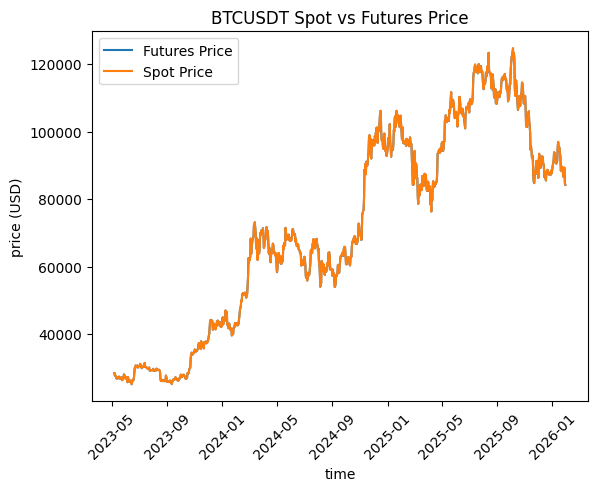

In [ ]:
import matplotlib.pyplot as plt


x = df1["timestamp"]
#plt.xticks(rotation=45)

y1 = df1["fut_price"]

y2 = df1["spot_price"]


fig, ax = plt.subplots()

ax.plot(x, y1, label="Futures Price")
ax.plot(x, y2, label="Spot Price")


ax.set_xlabel("time")

ax.set_ylabel("price (USD)")

ax.set_title("BTCUSDT Spot vs Futures Price")

ax.legend()
plt.xticks(rotation=45)

plt.show()

## Feature Creation

### Feature Creation - Spread & Spread PCT and then plotting

In [ ]:
spread = df1["spot_price"] - df1["fut_price"]

spread_pct = spread / df1["spot_price"]

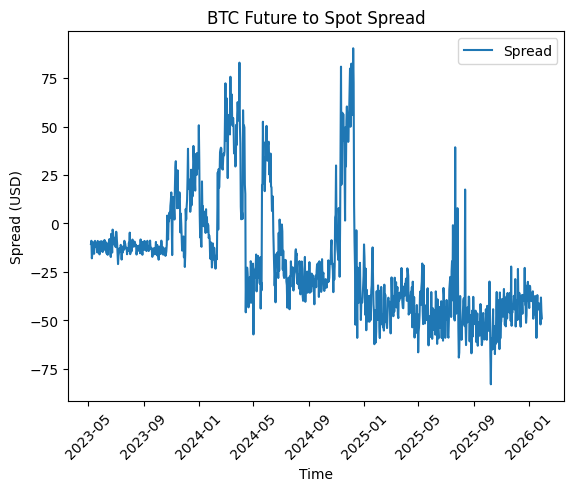

In [ ]:
#plotting spread

y3 = spread

y4 = spread_pct

fig, ax = plt.subplots()
ax.plot(x, y3, label="Spread")
#ax.plot(x, y4, label="Spread Percentage")

ax.set_xlabel("Time")
ax.set_ylabel("Spread (USD)")
ax.set_title("BTC Future to Spot Spread")

ax.legend()
plt.xticks(rotation=45)

plt.show()

### Feature Creation & Plotting - rolling_mean, rolling_std & z score

In [ ]:
rolling_mean = spread_pct.rolling(window=20).mean()
rolling_std = spread_pct.rolling(window=20).std()

z_score = (
    (spread_pct - rolling_mean) /
    rolling_std
)

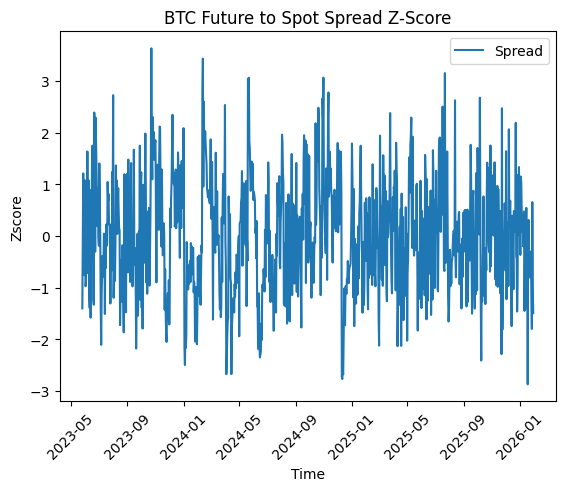

In [ ]:
#plotting spread z score

y5 = z_score


fig, ax = plt.subplots()
ax.plot(x, y5, label="Spread")


ax.set_xlabel("Time")
ax.set_ylabel("Zscore")
ax.set_title("BTC Future to Spot Spread Z-Score")

ax.legend()
plt.xticks(rotation=45)

plt.show()

### Feature Creation - funding rate

Getting Raw Data

In [ ]:
print(start_time)

1683409660096


In [4]:
import requests
import pandas as pd

url = "https://fapi.binance.com/fapi/v1/fundingRate"

all_data = []
current_start = start_time

while current_start < end_time:
    paramsf = {
        "symbol": "BTCUSDT",
        "startTime": current_start,
        "endTime": end_time,
        "limit": 1000
    }

    responsef = requests.get(url, params= paramsf)

    dataf = responsef.json()

    if not dataf:
        break

    all_data.extend(dataf)

    last_time = dataf[-1]["fundingTime"]
    current_start = last_time + 1

    print(f"Pulled up to: {pd.to_datetime(last_time, unit='ms')}")

    time.sleep(0.1)

funding_df = pd.DataFrame(all_data)

funding_df.head()



NameError: name 'start_time' is not defined

In [3]:
funding_df.to_csv("fundingrate.csv", index=False)

NameError: name 'funding_df' is not defined

Cleaning funding data

In [ ]:
funding_df["fundingRate"] = funding_df["fundingRate"].astype(float)
funding_df["fundingTime"] = pd.to_datetime(funding_df["fundingTime"], unit="ms")

funding_df =funding_df.rename(columns={
    "fundingTime": "timestamp",
    "fundingRate": "funding_rate"
})
funding_df.head()

,symbol,timestamp,funding_rate,markPrice
0,BTCUSDT,2023-05-07 00:00:00.000,0.000043,
1,BTCUSDT,2023-05-07 08:00:00.000,0.000040,
2,BTCUSDT,2023-05-07 16:00:00.006,0.000060,
3,BTCUSDT,2023-05-08 00:00:00.000,0.000007,
4,BTCUSDT,2023-05-08 08:00:00.007,0.000004,


In [ ]:
funding_df = funding_df.sort_values("timestamp")

funding_df

,symbol,timestamp,funding_rate,markPrice
0,BTCUSDT,2023-05-07,0.000043,
1,BTCUSDT,2023-05-07,0.000040,
2,BTCUSDT,2023-05-07,0.000060,
3,BTCUSDT,2023-05-08,0.000007,
4,BTCUSDT,2023-05-08,0.000004,
...,...,...,...,...
3279,BTCUSDT,2026-05-04,0.000043,78528.90000000
3281,BTCUSDT,2026-05-04,-0.000032,79981.20000000
3283,BTCUSDT,2026-05-05,-0.000046,80823.36977536
3282,BTCUSDT,2026-05-05,-0.000004,79826.10000000


### Clean Feature adding to one data set

In [ ]:
df1["spread"] = df1["spot_price"] - df1["fut_price"]
df1["spread_pct"] = df1["spread"]/df1["spot_price"]
df1["rolling_mean"] = df1["spread_pct"].rolling(20).mean()
df1["rolling_std"] = df1["spread_pct"].rolling(20).std()

df1["zscore"] = (
    (df1["spread_pct"] - df1["rolling_mean"]) / df1["rolling_std"]
)

df1.head()

#Always keep features within one big dataset thet they're derived from

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore
0,2023-05-07,28430.10,28419.4,10.70,0.000376,NaN,NaN,NaN
1,2023-05-08,27668.79,27659.8,8.99,0.000325,NaN,NaN,NaN
2,2023-05-09,27628.27,27610.2,18.07,0.000654,NaN,NaN,NaN
3,2023-05-10,27598.75,27582.9,15.85,0.000574,NaN,NaN,NaN
4,2023-05-11,26968.62,26956.4,12.22,0.000453,NaN,NaN,NaN


Adding funding to the dataset

In [ ]:
funding_df

,symbol,timestamp,funding_rate
0,BTCUSDT,2023-05-07,0.0000432100
1,BTCUSDT,2023-05-07,0.0000404700
2,BTCUSDT,2023-05-07,0.0000604600
3,BTCUSDT,2023-05-08,0.0000072000
4,BTCUSDT,2023-05-08,0.0000040700
...,...,...,...
3279,BTCUSDT,2026-05-04,0.0000430400
3281,BTCUSDT,2026-05-04,-0.0000316000
3283,BTCUSDT,2026-05-05,-0.0000462600
3282,BTCUSDT,2026-05-05,-0.0000038300


In [ ]:
funding_df["timestamp"] = funding_df["timestamp"].dt.floor("D")

funding_df["date"] = (
    funding_df["timestamp"].dt.date
)

daily_funding = (
    funding_df
    .groupby("date")["funding_rate"]
    .sum()
    .reset_index()
)

daily_funding = daily_funding.rename(columns={"funding_rate":"daily_funding"})
#funding_df = funding_df.drop(columns=["markPrice"])

#funding_df.head()
"""
df1 = stats_df.merge(
    funding_df,
    on="date",
    how="left"
)
"""
daily_funding

,date,daily_funding
0,2023-05-07,0.0001441400
1,2023-05-08,0.0000502900
2,2023-05-09,0.0001232900
3,2023-05-10,0.0001232900
4,2023-05-11,0.0001372900
...,...,...
1090,2026-05-01,-0.0000869900
1091,2026-05-02,-0.0000846500
1092,2026-05-03,0.0000159500
1093,2026-05-04,0.0000098600


In [ ]:
stats_df["date"] = (
    stats_df["timestamp"].dt.date
)

stats_df = stats_df.merge(
    daily_funding,
    on="date",
    how="left"
)

In [ ]:
stats_df.head()

,timestamp,spot_price,fut_price,funding_rate,spread,spread_pct,rolling_mean,rolling_std,zscore,positions,spot_return,fut_return,strategy_returns,equity,cumulative_return,pnl,cumulative_return_pct,date,daily_funding
0,2023-05-07,28430.1000000000,28419.4000000000,0.0000432100,10.7000000000,0.0003763617,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0000000000,1.0000000000,0.0000000000,0.0000000000,2023-05-07,0.0001441400
1,2023-05-07,28430.1000000000,28419.4000000000,0.0000432100,10.7000000000,0.0003763617,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0000000000,1.0000000000,0.0000000000,0.0000000000,2023-05-07,0.0001441400
2,2023-05-07,28430.1000000000,28419.4000000000,0.0000432100,10.7000000000,0.0003763617,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0000000000,1.0000000000,0.0000000000,0.0000000000,2023-05-07,0.0001441400
3,2023-05-07,28430.1000000000,28419.4000000000,0.0000404700,10.7000000000,0.0003763617,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0000000000,1.0000000000,0.0000000000,0.0000000000,2023-05-07,0.0001441400
4,2023-05-07,28430.1000000000,28419.4000000000,0.0000404700,10.7000000000,0.0003763617,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0000000000,1.0000000000,0.0000000000,0.0000000000,2023-05-07,0.0001441400


In [ ]:
stats_df = df1.copy()

stats_df = stats_df.drop(columns=["symbol_x", "symbol_y", "funding_rate_y"])

stats_df.head()

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore,positions,spot_return,fut_return,strategy_returns,equity,cumulative_return,pnl,cumulative_return_pct,funding_rate_x
0,2023-05-07,28430.1,28419.4,10.7,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0,1.0,0.0,0.0,0.000043
1,2023-05-07,28430.1,28419.4,10.7,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0,1.0,0.0,0.0,0.000043
2,2023-05-07,28430.1,28419.4,10.7,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0,1.0,0.0,0.0,0.000043
3,2023-05-07,28430.1,28419.4,10.7,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0,1.0,0.0,0.0,0.000040
4,2023-05-07,28430.1,28419.4,10.7,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0,1.0,0.0,0.0,0.000040


In [ ]:
#moving funding rate to the 4th column
col = stats_df.pop("funding_rate_x")
stats_df.insert(3, "funding_rate", col)

stats_df.head()

,timestamp,spot_price,fut_price,funding_rate,spread,spread_pct,rolling_mean,rolling_std,zscore,positions,spot_return,fut_return,strategy_returns,equity,cumulative_return,pnl,cumulative_return_pct
0,2023-05-07,28430.1,28419.4,0.000043,10.7,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0,1.0,0.0,0.0
1,2023-05-07,28430.1,28419.4,0.000043,10.7,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0,1.0,0.0,0.0
2,2023-05-07,28430.1,28419.4,0.000043,10.7,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0,1.0,0.0,0.0
3,2023-05-07,28430.1,28419.4,0.000040,10.7,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0,1.0,0.0,0.0
4,2023-05-07,28430.1,28419.4,0.000040,10.7,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0,1.0,0.0,0.0


## Signal Creation and Analysis

In [ ]:
#print(z_score)
df_z = pd.DataFrame(z_score)
df_z.columns = ["zscore"]


stats_df = pd.concat([df1["timestamp"], df_z["zscore"]], axis=1).copy()

short_signal = z_score > 2
long_signal = z_score < -2

long_count = (stats_df["zscore"]<-1).sum()
print(long_count)

short_count = (stats_df["zscore"] > 1).sum()
print(short_count)

total = len(stats_df)

long_freq = long_count/total
short_freq = short_count/total

print(long_freq)
print(short_freq)

182
182
0.182
0.182


### Creating short and long signals

In [ ]:
short_signal = (stats_df["zscore"]>1) & (stats_df["zscore"].shift(1) <= 1)
short_events = short_signal.sum()

long_signal = (stats_df["zscore"]<-1) & (stats_df["zscore"].shift(1) >=-1)
long_events = long_signal.sum()

print(long_events)
print(short_events)

106
107


In [ ]:
#analysis of signals per month

#First aligning all short signals with their respective date
short_df = pd.DataFrame({"timestamp": stats_df["timestamp"],
                         "shortsig": short_signal})

#short_df.head()

#Timestamped short signals
display(short_df.loc[(short_df["shortsig"]==True)])


In [ ]:
#Understanding the number of short signals per month

short_df = stats_df.loc[short_signal].copy()

short_df["month"] = short_df["timestamp"].dt.to_period("M")

monthly_counts = short_df.groupby("month").size()

print(monthly_counts)

month
2023-05    2
2023-06    5
2023-07    3
2023-08    5
2023-09    5
2023-10    3
2023-11    3
2023-12    6
2024-01    1
2024-02    3
2024-03    4
2024-05    5
2024-07    3
2024-08    2
2024-09    6
2024-10    3
2024-11    4
2024-12    2
2025-01    2
2025-02    1
2025-03    4
2025-04    2
2025-05    5
2025-06    3
2025-07    6
2025-08    1
2025-09    2
2025-10    6
2025-11    3
2025-12    5
2026-01    1
Freq: M, dtype: int64


Understanding the nature of the mean reversion

In [ ]:
#Lists each entry point as short_signal is boolean so it provides timestamp for every true entry
signal_indices = stats_df.index[short_signal]

holding_periods = []

for idx in signal_indices:
    future_data = stats_df.loc[idx+1:]

    reversion = future_data[future_data["zscore"]<=0]

    if not reversion.empty:
        t1 = reversion.index[0]
        holding_period = t1-idx
        holding_periods.append(holding_period)

print("Average days to mean revert:", np.mean(holding_periods))
print("Median:", np.median(holding_periods))
print("Max:", np.max(holding_periods))

Average days to mean revert: 4.028301886792453
Median: 2.0
Max: 23


### Signal Creation including funding rate

In [ ]:
short_signalf = (
    (stats_df["zscore"] > 1) &
    (stats_df["funding_rate"] > 0)
)

long_signalf = (
    (stats_df["zscore"] <-1) &
    (stats_df["funding_rate"] < 0)
)

### First PNL Creation - done wrong 
Adding PNL to understand the mean reversion visually and numerically

In [ ]:
#pnl = entry_spread - current_spread

trades = []

for idx in signal_indices:
    entry_row = stats_df.loc[idx]
    entry_spread = entry_row["spread_pct"]

    future_data = stats_df.loc[idx+1:].copy()

    reversion = future_data[future_data["zscore"] <=0]

    trade = {}

    if not reversion.empty:
        t1 = reversion.index[0]
        trade_data = stats_df.loc[idx:t1].copy()
        reverted = True
    else:
        #trade doesn't revert, allow it to take the full path
        trade_data = stats_df.loc[idx:].copy()
        t1 = trade_data.index[-1]
        reverted = False
    
    holding_period = (
        stats_df.loc[t1, "timestamp"] - entry_row["timestamp"]
    ).days

    #pnl path
    trade_data["pnl"] = entry_spread - trade_data["spread_pct"]


    #final pnl
    final_pnl = trade_data["pnl"].iloc[-1]

    trade["entry_idx"] = idx
    trade["exit_idx"] = t1
    trade["holding_period"] = holding_period
    trade["final_pnl"] = final_pnl
    trade["reverted"] = reverted
    trade ["pnl_path"] = trade_data["pnl"].values

    trades.append(trade)






In [ ]:
trades_df = pd.DataFrame(trades)

trades_df.head()

trade_data.head()

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore,pnl
972,2026-01-03,90628.01,90595.8,32.21,0.000355,0.000444,0.000077,-1.152415,0.000000
973,2026-01-04,91529.73,91497.1,32.63,0.000356,0.000437,0.000078,-1.030515,-0.000001


<Axes: >

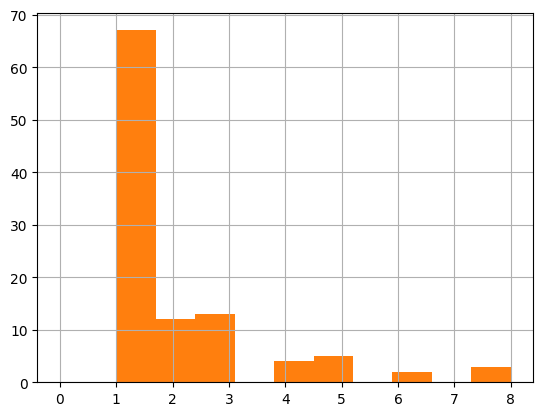

In [ ]:
trades_df["final_pnl"].hist()
trades_df["holding_period"].hist()

In [ ]:
trades_df.groupby("reverted")["final_pnl"].mean()

reverted
True   -0.000053
Name: final_pnl, dtype: float64

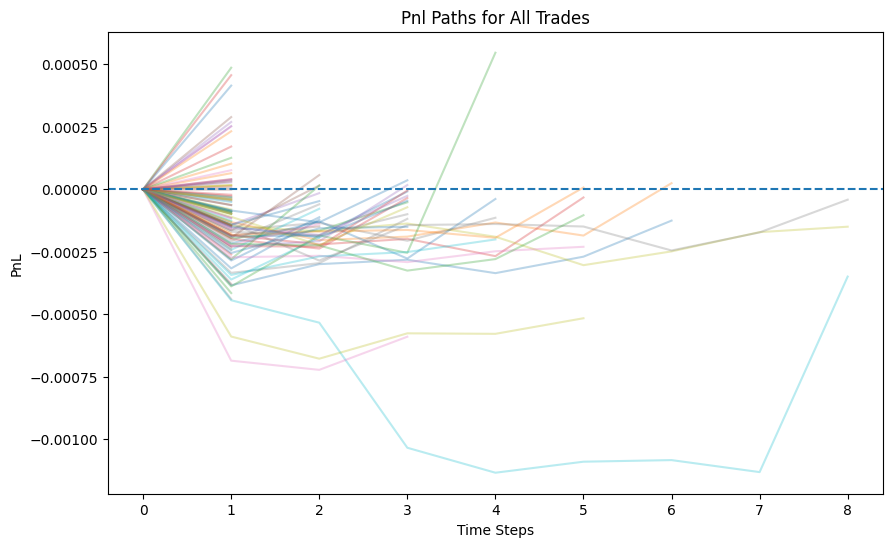

In [ ]:
plt.figure(figsize=(10,6))

for trade in trades:
    plt.plot(trade["pnl_path"], alpha=0.3)

plt.axhline(0, linestyle="--") #this shows breakeven line
plt.title("Pnl Paths for All Trades")
plt.xlabel("Time Steps")
plt.ylabel("PnL")
plt.show()


In [ ]:
trades_df["returns"] = trades_df["final_pnl"]

initial_capital = 1000

equity = [initial_capital]

for r in trades_df["returns"]:
    new_equity = equity[-1] * (1+r)
    equity.append(new_equity)

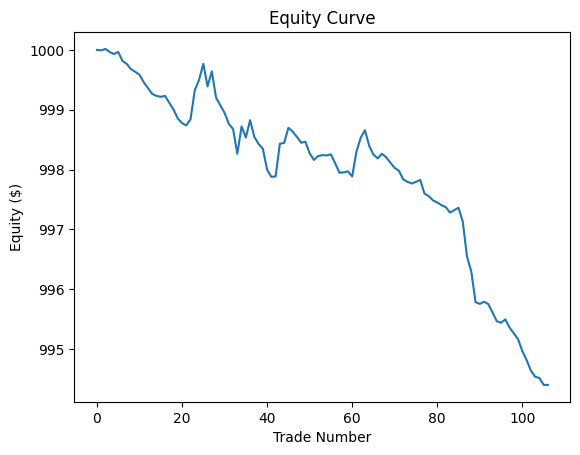

In [ ]:
plt.plot(equity)
plt.title("Equity Curve")
plt.xlabel("Trade Number")
plt.ylabel("Equity ($)")
plt.show()

## PNL Creation

In [ ]:
stats_df.head()

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore
0,2023-05-07,28430.10,28419.4,10.70,0.000376,NaN,NaN,NaN
1,2023-05-08,27668.79,27659.8,8.99,0.000325,NaN,NaN,NaN
2,2023-05-09,27628.27,27610.2,18.07,0.000654,NaN,NaN,NaN
3,2023-05-10,27598.75,27582.9,15.85,0.000574,NaN,NaN,NaN
4,2023-05-11,26968.62,26956.4,12.22,0.000453,NaN,NaN,NaN


# Trading zscore

## Trading Logic and Backtest

In [ ]:
#building trading logic
#building the position column
stats_df["positions"] = 0

current_pos = 0

positions = []

for i in range(len(stats_df)):
    z = stats_df["zscore"].iloc[i]

    #entry
    if current_pos == 0:
        if z > 1:
            current_pos = -1
        elif z < -1:
            current_pos = 1
    
    #exit
    elif current_pos == -1 and z <= 0:
        current_pos = 0
    elif current_pos == 1 and z >= 0:
        current_pos = 0
    
    positions.append(current_pos)

stats_df["positions"] = positions

In [ ]:
stats_df

NameError: name 'stats_df' is not defined

In [ ]:
stats_df["spot_return"] = stats_df["spot_price"].pct_change()
stats_df["fut_return"] = stats_df["fut_price"].pct_change()

In [ ]:
stats_df

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore,positions,spot_return,fut_return
0,2023-05-07,28430.10,28419.4,10.70,0.000376,NaN,NaN,NaN,0,NaN,NaN
1,2023-05-08,27668.79,27659.8,8.99,0.000325,NaN,NaN,NaN,0,-0.026778,-0.026728
2,2023-05-09,27628.27,27610.2,18.07,0.000654,NaN,NaN,NaN,0,-0.001464,-0.001793
3,2023-05-10,27598.75,27582.9,15.85,0.000574,NaN,NaN,NaN,0,-0.001068,-0.000989
4,2023-05-11,26968.62,26956.4,12.22,0.000453,NaN,NaN,NaN,0,-0.022832,-0.022713
...,...,...,...,...,...,...,...,...,...,...,...
995,2026-01-26,88347.08,88300.6,46.48,0.000526,0.000462,0.000059,1.084643,-1,0.019346,0.019297
996,2026-01-27,89250.00,89197.8,52.20,0.000585,0.000471,0.000063,1.797759,-1,0.010220,0.010161
997,2026-01-28,89299.99,89261.7,38.29,0.000429,0.000471,0.000064,-0.656443,0,0.000560,0.000716
998,2026-01-29,84650.16,84604.7,45.46,0.000537,0.000477,0.000064,0.945604,0,-0.052070,-0.052172


In [ ]:
stats_df["strategy_returns"] = (
    stats_df["positions"].shift(1) *
    (stats_df["spot_return"] - stats_df["fut_return"])
)

In [ ]:
stats_df

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore,positions,spot_return,fut_return,strategy_returns
0,2023-05-07,28430.10,28419.4,10.70,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN
1,2023-05-08,27668.79,27659.8,8.99,0.000325,NaN,NaN,NaN,0,-0.026778,-0.026728,-0.000000
2,2023-05-09,27628.27,27610.2,18.07,0.000654,NaN,NaN,NaN,0,-0.001464,-0.001793,0.000000
3,2023-05-10,27598.75,27582.9,15.85,0.000574,NaN,NaN,NaN,0,-0.001068,-0.000989,-0.000000
4,2023-05-11,26968.62,26956.4,12.22,0.000453,NaN,NaN,NaN,0,-0.022832,-0.022713,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026-01-26,88347.08,88300.6,46.48,0.000526,0.000462,0.000059,1.084643,-1,0.019346,0.019297,0.000000
996,2026-01-27,89250.00,89197.8,52.20,0.000585,0.000471,0.000063,1.797759,-1,0.010220,0.010161,-0.000059
997,2026-01-28,89299.99,89261.7,38.29,0.000429,0.000471,0.000064,-0.656443,0,0.000560,0.000716,0.000156
998,2026-01-29,84650.16,84604.7,45.46,0.000537,0.000477,0.000064,0.945604,0,-0.052070,-0.052172,0.000000


### Adding Equity
Numerically visualising pnl

In [ ]:
initial_cap = 10000

stats_df["equity"] = (
    (1 + stats_df["strategy_returns"].fillna(0))
    .cumprod() * initial_cap
)

In [ ]:
stats_df

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore,positions,spot_return,fut_return,strategy_returns,equity,cumulative_return
0,2023-05-07,28430.10,28419.4,10.70,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.000000,1.0
1,2023-05-08,27668.79,27659.8,8.99,0.000325,NaN,NaN,NaN,0,-0.026778,-0.026728,-0.000000,10000.000000,1.0
2,2023-05-09,27628.27,27610.2,18.07,0.000654,NaN,NaN,NaN,0,-0.001464,-0.001793,0.000000,10000.000000,1.0
3,2023-05-10,27598.75,27582.9,15.85,0.000574,NaN,NaN,NaN,0,-0.001068,-0.000989,-0.000000,10000.000000,1.0
4,2023-05-11,26968.62,26956.4,12.22,0.000453,NaN,NaN,NaN,0,-0.022832,-0.022713,-0.000000,10000.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026-01-26,88347.08,88300.6,46.48,0.000526,0.000462,0.000059,1.084643,-1,0.019346,0.019297,0.000000,10297.077581,1.0
996,2026-01-27,89250.00,89197.8,52.20,0.000585,0.000471,0.000063,1.797759,-1,0.010220,0.010161,-0.000059,10296.465944,1.0
997,2026-01-28,89299.99,89261.7,38.29,0.000429,0.000471,0.000064,-0.656443,0,0.000560,0.000716,0.000156,10298.075008,1.0
998,2026-01-29,84650.16,84604.7,45.46,0.000537,0.000477,0.000064,0.945604,0,-0.052070,-0.052172,0.000000,10298.075008,1.0


## Visualising backtest

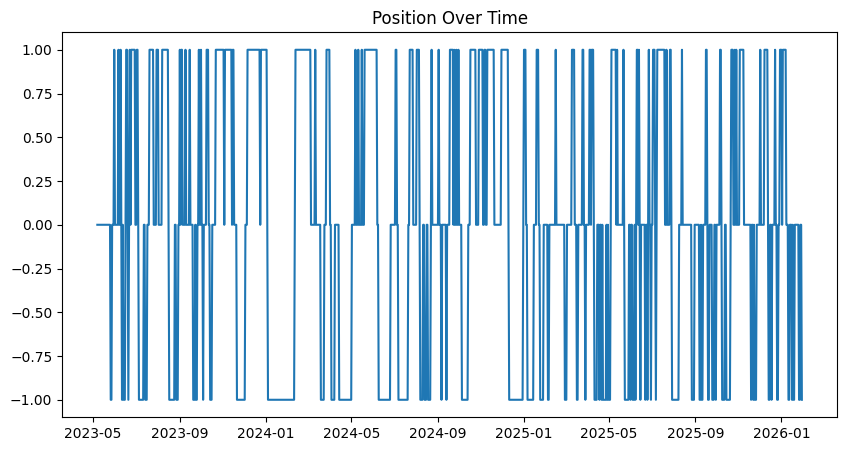

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(stats_df["timestamp"], stats_df["positions"])
plt.title("Position Over Time")
plt.show()

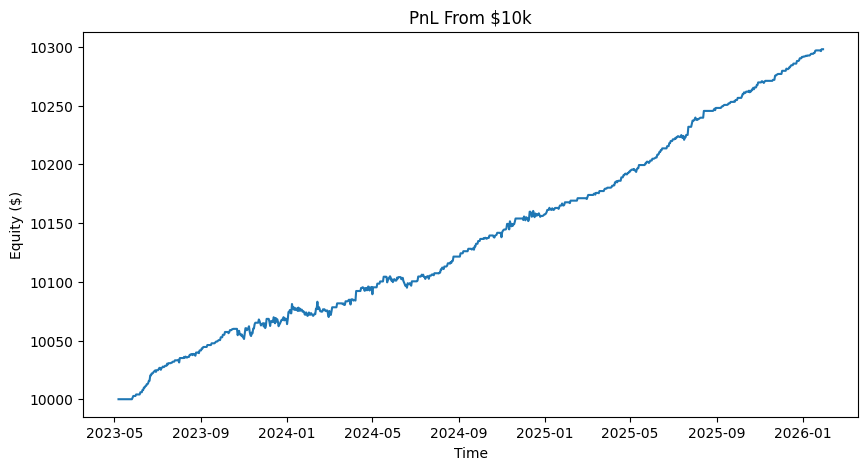

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(stats_df["timestamp"], stats_df["equity"])
plt.title("PnL From $10k")
plt.xlabel("Time")
plt.ylabel("Equity ($)")
plt.show()

Performance Metrics

In [ ]:
"""
To complete

1. The performance stats - cumulative returns, sharpe ratio, max drawdown, win rate

2. Add funding rates

3. Rebuild everything on the 1hr time level -  need to add loop to get through the 1000 rate limit

4. Add slippage and transaction costs

5. Build this to trade incoming data and have this running for 24hrs and see how it does

6. Rewrite everything with more optimised code
"""



## Performance Metrics

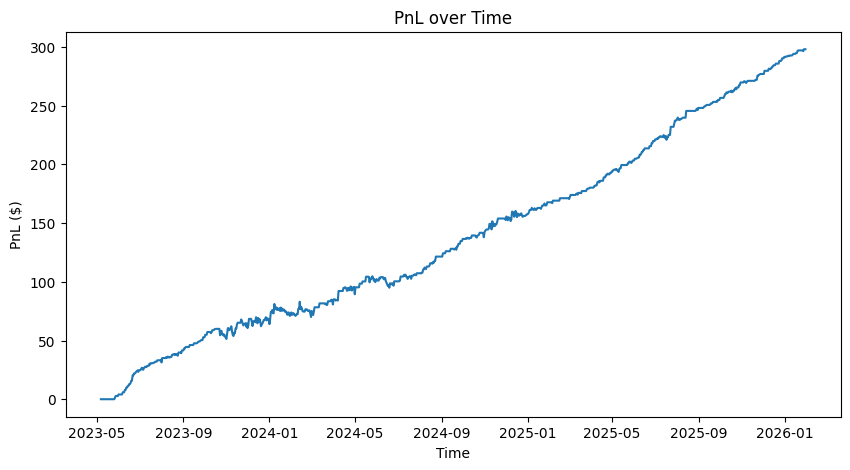

In [ ]:
#pnl
stats_df["pnl"] = stats_df["equity"] - initial_cap

plt.figure(figsize=(10,5))
plt.plot(stats_df["timestamp"], stats_df["pnl"], label="pnl")
plt.title("PnL over Time")
plt.xlabel("Time")
plt.ylabel("PnL ($)")
plt.show()

In [ ]:
#cumulative return
initial_capital = 10000
stats_df["cumulative_return"] = stats_df["equity"] / initial_capital

stats_df

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore,positions,spot_return,fut_return,strategy_returns,equity,cumulative_return,pnl
0,2023-05-07,28430.10,28419.4,10.70,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.000000,1.000000,0.000000
1,2023-05-08,27668.79,27659.8,8.99,0.000325,NaN,NaN,NaN,0,-0.026778,-0.026728,-0.000000,10000.000000,1.000000,0.000000
2,2023-05-09,27628.27,27610.2,18.07,0.000654,NaN,NaN,NaN,0,-0.001464,-0.001793,0.000000,10000.000000,1.000000,0.000000
3,2023-05-10,27598.75,27582.9,15.85,0.000574,NaN,NaN,NaN,0,-0.001068,-0.000989,-0.000000,10000.000000,1.000000,0.000000
4,2023-05-11,26968.62,26956.4,12.22,0.000453,NaN,NaN,NaN,0,-0.022832,-0.022713,-0.000000,10000.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026-01-26,88347.08,88300.6,46.48,0.000526,0.000462,0.000059,1.084643,-1,0.019346,0.019297,0.000000,10297.077581,1.029708,297.077581
996,2026-01-27,89250.00,89197.8,52.20,0.000585,0.000471,0.000063,1.797759,-1,0.010220,0.010161,-0.000059,10296.465944,1.029647,296.465944
997,2026-01-28,89299.99,89261.7,38.29,0.000429,0.000471,0.000064,-0.656443,0,0.000560,0.000716,0.000156,10298.075008,1.029808,298.075008
998,2026-01-29,84650.16,84604.7,45.46,0.000537,0.000477,0.000064,0.945604,0,-0.052070,-0.052172,0.000000,10298.075008,1.029808,298.075008


In [ ]:
stats_df["cumulative_return_pct"] = (stats_df["cumulative_return"] - 1)*100

stats_df

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore,positions,spot_return,fut_return,strategy_returns,equity,cumulative_return,pnl,cumulative_return_pct
0,2023-05-07,28430.10,28419.4,10.70,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.000000,1.000000,0.000000,0.000000
1,2023-05-08,27668.79,27659.8,8.99,0.000325,NaN,NaN,NaN,0,-0.026778,-0.026728,-0.000000,10000.000000,1.000000,0.000000,0.000000
2,2023-05-09,27628.27,27610.2,18.07,0.000654,NaN,NaN,NaN,0,-0.001464,-0.001793,0.000000,10000.000000,1.000000,0.000000,0.000000
3,2023-05-10,27598.75,27582.9,15.85,0.000574,NaN,NaN,NaN,0,-0.001068,-0.000989,-0.000000,10000.000000,1.000000,0.000000,0.000000
4,2023-05-11,26968.62,26956.4,12.22,0.000453,NaN,NaN,NaN,0,-0.022832,-0.022713,-0.000000,10000.000000,1.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026-01-26,88347.08,88300.6,46.48,0.000526,0.000462,0.000059,1.084643,-1,0.019346,0.019297,0.000000,10297.077581,1.029708,297.077581,2.970776
996,2026-01-27,89250.00,89197.8,52.20,0.000585,0.000471,0.000063,1.797759,-1,0.010220,0.010161,-0.000059,10296.465944,1.029647,296.465944,2.964659
997,2026-01-28,89299.99,89261.7,38.29,0.000429,0.000471,0.000064,-0.656443,0,0.000560,0.000716,0.000156,10298.075008,1.029808,298.075008,2.980750
998,2026-01-29,84650.16,84604.7,45.46,0.000537,0.000477,0.000064,0.945604,0,-0.052070,-0.052172,0.000000,10298.075008,1.029808,298.075008,2.980750


In [ ]:
import numpy as np
#sharpe ratio
returns = stats_df["strategy_returns"].dropna()

sharpe = returns.mean() / returns.std()

sharpe = sharpe * np.sqrt(365)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 3.93225437081143


Sharpe is high because the reeturns are tiny but the volatility is even tinier. The spread cancels out because of the market neutral nature of the trade. It completely cancels out the market direction and most of the volatility so the sharp looks amazing

Max drawdown: -0.0012876442245087563


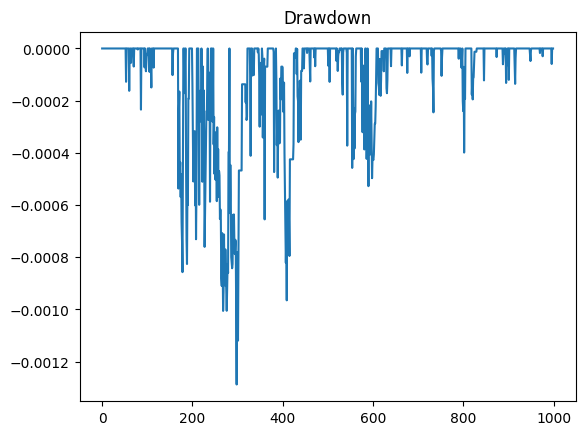

In [ ]:
#max drawdown
equity = stats_df["equity"]

rolling_max = equity.cummax()

drawdown = (equity - rolling_max)/ rolling_max


max_drawdown = drawdown.min()

print("Max drawdown:", max_drawdown)

plt.plot(drawdown)
plt.title("Drawdown")
plt.show()

In [ ]:
#win rate
win_rate = (trades_df["final_pnl"] > 0).mean()

print("Win rate:", win_rate)

Win rate: 0.2830188679245283


In [ ]:
print(stats_df["spot_return"].std())
print(stats_df["fut_return"].std())
print((stats_df["spot_return"] - stats_df["fut_return"].std()))

0.023799304218712816
0.023836054985291732
0           NaN
1     -0.050614
2     -0.025301
3     -0.024905
4     -0.046668
         ...   
995   -0.004490
996   -0.013616
997   -0.023276
998   -0.075906
999   -0.028439
Name: spot_return, Length: 1000, dtype: float64


In [ ]:
stats_df

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore,positions,spot_return,fut_return,strategy_returns,equity,cumulative_return,pnl,cumulative_return_pct
0,2023-05-07,28430.10,28419.4,10.70,0.000376,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.000000,1.000000,0.000000,0.000000
1,2023-05-08,27668.79,27659.8,8.99,0.000325,NaN,NaN,NaN,0,-0.026778,-0.026728,-0.000000,10000.000000,1.000000,0.000000,0.000000
2,2023-05-09,27628.27,27610.2,18.07,0.000654,NaN,NaN,NaN,0,-0.001464,-0.001793,0.000000,10000.000000,1.000000,0.000000,0.000000
3,2023-05-10,27598.75,27582.9,15.85,0.000574,NaN,NaN,NaN,0,-0.001068,-0.000989,-0.000000,10000.000000,1.000000,0.000000,0.000000
4,2023-05-11,26968.62,26956.4,12.22,0.000453,NaN,NaN,NaN,0,-0.022832,-0.022713,-0.000000,10000.000000,1.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2026-01-26,88347.08,88300.6,46.48,0.000526,0.000462,0.000059,1.084643,-1,0.019346,0.019297,0.000000,10297.077581,1.029708,297.077581,2.970776
996,2026-01-27,89250.00,89197.8,52.20,0.000585,0.000471,0.000063,1.797759,-1,0.010220,0.010161,-0.000059,10296.465944,1.029647,296.465944,2.964659
997,2026-01-28,89299.99,89261.7,38.29,0.000429,0.000471,0.000064,-0.656443,0,0.000560,0.000716,0.000156,10298.075008,1.029808,298.075008,2.980750
998,2026-01-29,84650.16,84604.7,45.46,0.000537,0.000477,0.000064,0.945604,0,-0.052070,-0.052172,0.000000,10298.075008,1.029808,298.075008,2.980750


# Trading zscore & funding rate

## Trading Logic and Backtest

In [ ]:
statsf_df = stats_df.copy()

In [ ]:
statsf_df

,timestamp,spot_price,fut_price,funding_rate,spread,spread_pct,rolling_mean,rolling_std,zscore,positions,spot_return,fut_return,strategy_returns,equity,cumulative_return,pnl,cumulative_return_pct,date,daily_funding
0,2023-05-07,28430.1000000000,28419.4000000000,0.0000432100,10.7000000000,0.0003763617,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0000000000,1.0000000000,0.0000000000,0.0000000000,2023-05-07,0.0001441400
1,2023-05-07,28430.1000000000,28419.4000000000,0.0000432100,10.7000000000,0.0003763617,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0000000000,1.0000000000,0.0000000000,0.0000000000,2023-05-07,0.0001441400
2,2023-05-07,28430.1000000000,28419.4000000000,0.0000432100,10.7000000000,0.0003763617,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0000000000,1.0000000000,0.0000000000,0.0000000000,2023-05-07,0.0001441400
3,2023-05-07,28430.1000000000,28419.4000000000,0.0000404700,10.7000000000,0.0003763617,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0000000000,1.0000000000,0.0000000000,0.0000000000,2023-05-07,0.0001441400
4,2023-05-07,28430.1000000000,28419.4000000000,0.0000404700,10.7000000000,0.0003763617,NaN,NaN,NaN,0,NaN,NaN,NaN,10000.0000000000,1.0000000000,0.0000000000,0.0000000000,2023-05-07,0.0001441400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,2026-01-30,84260.4900000000,84211.4000000000,0.0000171400,49.0900000000,0.0005825981,0.0004863479,0.0000644965,1.4923302651,-1,-0.0046032990,-0.0046486779,0.0000000000,10298.0750075114,1.0298075008,298.0750075114,2.9807500751,2026-01-30,0.0000650200
8996,2026-01-30,84260.4900000000,84211.4000000000,0.0000171400,49.0900000000,0.0005825981,0.0004863479,0.0000644965,1.4923302651,-1,-0.0046032990,-0.0046486779,0.0000000000,10298.0750075114,1.0298075008,298.0750075114,2.9807500751,2026-01-30,0.0000650200
8997,2026-01-30,84260.4900000000,84211.4000000000,0.0000031000,49.0900000000,0.0005825981,0.0004863479,0.0000644965,1.4923302651,-1,-0.0046032990,-0.0046486779,0.0000000000,10298.0750075114,1.0298075008,298.0750075114,2.9807500751,2026-01-30,0.0000650200
8998,2026-01-30,84260.4900000000,84211.4000000000,0.0000031000,49.0900000000,0.0005825981,0.0004863479,0.0000644965,1.4923302651,-1,-0.0046032990,-0.0046486779,0.0000000000,10298.0750075114,1.0298075008,298.0750075114,2.9807500751,2026-01-30,0.0000650200


In [ ]:
#cleaning up the columns in the new dataframe for a rebuild

col_to_drop = [
    "positions",
    "spot_return",
    "fut_return",
    "strategy_returns",
    "equity",
    "cumulative_return",
    "pnl",
    "cumulative_return_pct"
]

statsf_df = statsf_df.drop(columns= col_to_drop, errors="ignore")
statsf_df.head()



,timestamp,spot_price,fut_price,funding_rate,spread,spread_pct,rolling_mean,rolling_std,zscore,date,daily_funding
0,2023-05-07,28430.1000000000,28419.4000000000,0.0000432100,10.7000000000,0.0003763617,NaN,NaN,NaN,2023-05-07,0.0001441400
1,2023-05-07,28430.1000000000,28419.4000000000,0.0000432100,10.7000000000,0.0003763617,NaN,NaN,NaN,2023-05-07,0.0001441400
2,2023-05-07,28430.1000000000,28419.4000000000,0.0000432100,10.7000000000,0.0003763617,NaN,NaN,NaN,2023-05-07,0.0001441400
3,2023-05-07,28430.1000000000,28419.4000000000,0.0000404700,10.7000000000,0.0003763617,NaN,NaN,NaN,2023-05-07,0.0001441400
4,2023-05-07,28430.1000000000,28419.4000000000,0.0000404700,10.7000000000,0.0003763617,NaN,NaN,NaN,2023-05-07,0.0001441400


In [ ]:
statsf_df = statsf_df.drop(
    columns=["funding_rate"]
)

In [ ]:
statsf_df.head()

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore,date,daily_funding
0,2023-05-07,28430.1000000000,28419.4000000000,10.7000000000,0.0003763617,NaN,NaN,NaN,2023-05-07,0.0001441400
1,2023-05-07,28430.1000000000,28419.4000000000,10.7000000000,0.0003763617,NaN,NaN,NaN,2023-05-07,0.0001441400
2,2023-05-07,28430.1000000000,28419.4000000000,10.7000000000,0.0003763617,NaN,NaN,NaN,2023-05-07,0.0001441400
3,2023-05-07,28430.1000000000,28419.4000000000,10.7000000000,0.0003763617,NaN,NaN,NaN,2023-05-07,0.0001441400
4,2023-05-07,28430.1000000000,28419.4000000000,10.7000000000,0.0003763617,NaN,NaN,NaN,2023-05-07,0.0001441400


In [ ]:
col = statsf_df.pop("date")
statsf_df.insert(3, "date", col)

In [ ]:
col = statsf_df.pop("daily_funding")
statsf_df.insert(4, "daily_funding", col)

In [ ]:
statsf_df.head()

,timestamp,spot_price,fut_price,date,daily_funding,spread,spread_pct,rolling_mean,rolling_std,zscore
0,2023-05-07,28430.1000000000,28419.4000000000,2023-05-07,0.0001441400,10.7000000000,0.0003763617,NaN,NaN,NaN
1,2023-05-07,28430.1000000000,28419.4000000000,2023-05-07,0.0001441400,10.7000000000,0.0003763617,NaN,NaN,NaN
2,2023-05-07,28430.1000000000,28419.4000000000,2023-05-07,0.0001441400,10.7000000000,0.0003763617,NaN,NaN,NaN
3,2023-05-07,28430.1000000000,28419.4000000000,2023-05-07,0.0001441400,10.7000000000,0.0003763617,NaN,NaN,NaN
4,2023-05-07,28430.1000000000,28419.4000000000,2023-05-07,0.0001441400,10.7000000000,0.0003763617,NaN,NaN,NaN


In [ ]:
#position column
statsf_df["position"] = 0

In [ ]:
#trading logic

current_position = 0

for i in range(len(statsf_df)):
    z = stats_df["zscore"].iloc[i]

    #entry
    if current_position == 0:
        if short_signalf.iloc[i]:
            current_position = -1
        elif long_signalf.iloc[i]:
            current_position = 1
    
    #exit
    elif current_position == -1:
        if z <= 0:
            current_position = 0
    elif current_position == 1:
        if z >= 0:
            current_position = 0
    
    #store position
    statsf_df.loc[i, "position"] = current_position

In [ ]:
#building leg returns

statsf_df["spot_return"] = (
    statsf_df["spot_price"].pct_change()
)

statsf_df["fut_return"] = (
    statsf_df["fut_price"].pct_change()
)

In [ ]:
#building spread return
statsf_df["spread_return"] = (
    statsf_df["fut_return"] -
    statsf_df["spot_return"]
)


In [ ]:
#building funding pnl
statsf_df["funding_pnl"] = (
    -statsf_df["position"].shift(1) *
    statsf_df["daily_funding"]
)

In [ ]:
# building price pnl
statsf_df["price_pnl"] = (
    statsf_df["position"].shift(1) *
    statsf_df["spread_return"]
)

In [ ]:
# building strategy return
statsf_df["strategy_return"] = (
    statsf_df["funding_pnl"] +
    statsf_df["price_pnl"]
)

In [ ]:
# building equity
starting_capital = 10000
statsf_df["equity"] = (
    starting_capital *
    (1 + statsf_df["strategy_return"]).cumprod()
)

## Visualising Backtest

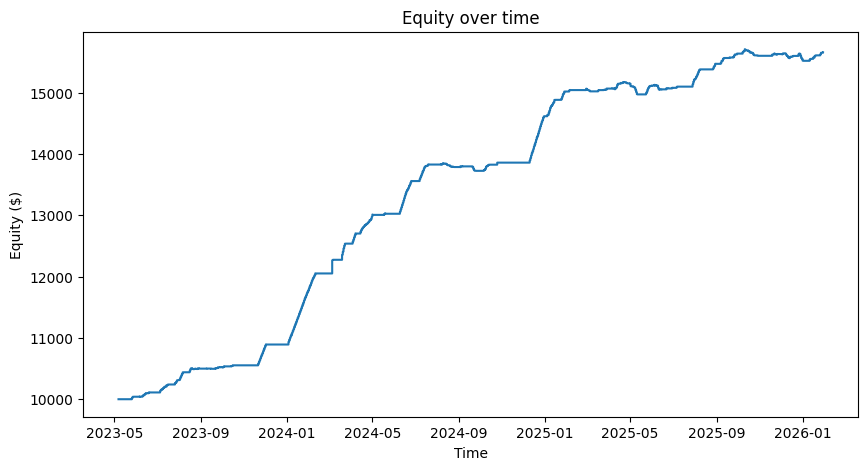

In [ ]:
#Plotting equity

plt.figure(figsize=(10,5))
plt.plot(statsf_df["timestamp"], statsf_df["equity"], label="equity")
plt.title("Equity over time")
plt.xlabel("Time")
plt.ylabel("Equity ($)")
plt.show()

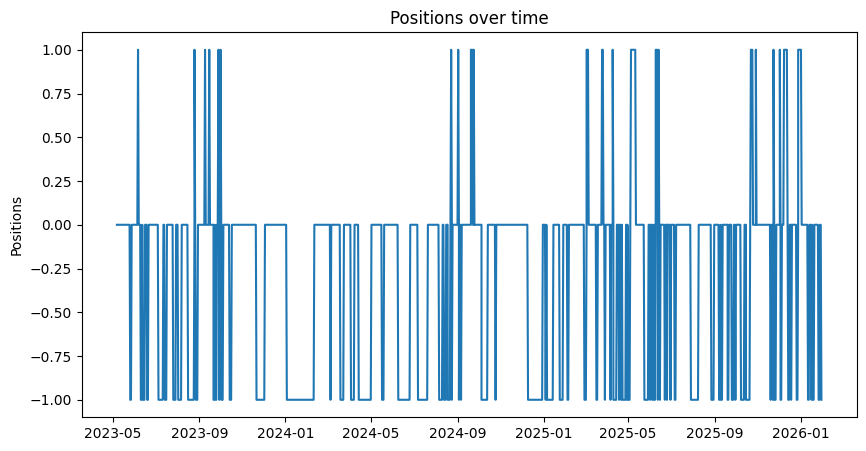

In [ ]:
#Plotting positions

plt.figure(figsize=(10,5))
plt.plot(statsf_df["timestamp"], statsf_df["position"])
plt.title("Positions over time")
plt.ylabel("Positions")
plt.show()

## Performance Metric Analysis

In [ ]:
#total funding contribution to pnl

statsf_df["price_pnl"].sum()

#pd.set_option("display.float_format", "{:.10f}".format)


np.float64(-0.01931846952811267)

In [ ]:
statsf_df["spot_price"].pct_change().head(20)

0              NaN
1     0.0000000000
2     0.0000000000
3     0.0000000000
4     0.0000000000
5     0.0000000000
6     0.0000000000
7     0.0000000000
8     0.0000000000
9    -0.0267783089
10    0.0000000000
11    0.0000000000
12    0.0000000000
13    0.0000000000
14    0.0000000000
15    0.0000000000
16    0.0000000000
17    0.0000000000
18   -0.0014644659
19    0.0000000000
Name: spot_price, dtype: float64

In [ ]:
#cumulative return
initial_capital = 10000
statsf_df["cumulative_return"] = statsf_df["equity"] / initial_capital

statsf_df

,timestamp,spot_price,fut_price,date,daily_funding,spread,spread_pct,rolling_mean,rolling_std,zscore,position,spot_return,fut_return,spread_return,funding_pnl,price_pnl,strategy_return,equity,cumulative_return
0,2023-05-07,28430.1000000000,28419.4000000000,2023-05-07,0.0001441400,10.7000000000,0.0003763617,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-05-07,28430.1000000000,28419.4000000000,2023-05-07,0.0001441400,10.7000000000,0.0003763617,NaN,NaN,NaN,0,0.0000000000,0.0000000000,0.0000000000,-0.0000000000,0.0000000000,0.0000000000,10000.0000000000,1.0000000000
2,2023-05-07,28430.1000000000,28419.4000000000,2023-05-07,0.0001441400,10.7000000000,0.0003763617,NaN,NaN,NaN,0,0.0000000000,0.0000000000,0.0000000000,-0.0000000000,0.0000000000,0.0000000000,10000.0000000000,1.0000000000
3,2023-05-07,28430.1000000000,28419.4000000000,2023-05-07,0.0001441400,10.7000000000,0.0003763617,NaN,NaN,NaN,0,0.0000000000,0.0000000000,0.0000000000,-0.0000000000,0.0000000000,0.0000000000,10000.0000000000,1.0000000000
4,2023-05-07,28430.1000000000,28419.4000000000,2023-05-07,0.0001441400,10.7000000000,0.0003763617,NaN,NaN,NaN,0,0.0000000000,0.0000000000,0.0000000000,-0.0000000000,0.0000000000,0.0000000000,10000.0000000000,1.0000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,2026-01-30,84260.4900000000,84211.4000000000,2026-01-30,0.0000650200,49.0900000000,0.0005825981,0.0004863479,0.0000644965,1.4923302651,-1,0.0000000000,0.0000000000,0.0000000000,0.0000650200,-0.0000000000,0.0000650200,15655.2869696042,1.5655286970
8996,2026-01-30,84260.4900000000,84211.4000000000,2026-01-30,0.0000650200,49.0900000000,0.0005825981,0.0004863479,0.0000644965,1.4923302651,-1,0.0000000000,0.0000000000,0.0000000000,0.0000650200,-0.0000000000,0.0000650200,15656.3048763630,1.5656304876
8997,2026-01-30,84260.4900000000,84211.4000000000,2026-01-30,0.0000650200,49.0900000000,0.0005825981,0.0004863479,0.0000644965,1.4923302651,-1,0.0000000000,0.0000000000,0.0000000000,0.0000650200,-0.0000000000,0.0000650200,15657.3228493061,1.5657322849
8998,2026-01-30,84260.4900000000,84211.4000000000,2026-01-30,0.0000650200,49.0900000000,0.0005825981,0.0004863479,0.0000644965,1.4923302651,-1,0.0000000000,0.0000000000,0.0000000000,0.0000650200,-0.0000000000,0.0000650200,15658.3408884377,1.5658340888


In [ ]:
mean_return = statsf_df["strategy_return"].mean()
volatility = statsf_df["strategy_return"].std()

sharpe_ratio = (
    mean_return / volatility
)

sharpe = sharpe_ratio * np.sqrt(365)

print("Annualised Sharpe: ",sharpe)

Annualised Sharpe:  7.11384404658502


Max drawdown: -0.013343438273369135


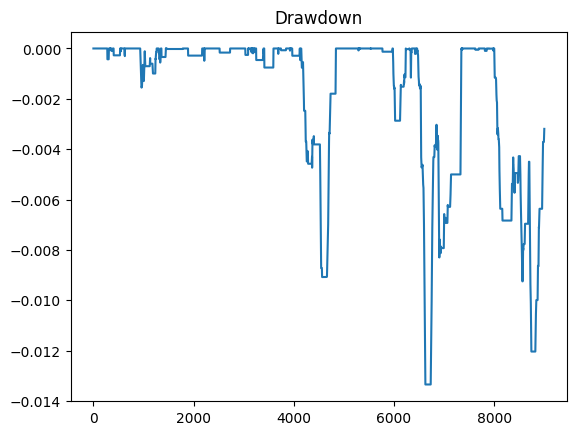

In [ ]:
#max drawdown
equity = statsf_df["equity"]

rolling_max = equity.cummax()

drawdown = (equity - rolling_max)/ rolling_max


max_drawdown = drawdown.min()

print("Max drawdown:", max_drawdown)

plt.plot(drawdown)
plt.title("Drawdown")
plt.show()

In [ ]:
win_rate = (
    statsf_df["strategy_return"] > 0
).mean()

print("Win rate: ", win_rate)

Win rate:  0.29233333333333333


In [ ]:
funding_cost = 0.0005

statsf_df["trade_change"] = (
    statsf_df["position"].diff().abs()
)

statsf_df["transaction_cost"] = (
    statsf_df["trade_change"] *
    0.0005
)

statsf_df["strategy_return"] = (
    statsf_df["price_pnl"] +
    statsf_df["funding_pnl"] -
    statsf_df["transaction_cost"]
)

In [ ]:
mean_return_tran = statsf_df["strategy_return"].mean()
volatility_tran = statsf_df["strategy_return"].std()

sharpe_ratio_tran = (
    mean_return_tran / volatility_tran
)

sharpe_tran = sharpe_ratio_tran * np.sqrt(365)

print("Annualised Sharpe: ",sharpe_tran)

Annualised Sharpe:  4.627157604229466


Where is the pnl coming from?

In [ ]:
statsf_df["price_pnl"].sum()

np.float64(-0.01931846952811267)

In [ ]:
statsf_df["funding_pnl"].sum()

np.float64(0.4678938999999999)

In [ ]:
statsf_df["transaction_cost"].sum()

np.float64(0.0995)

In [ ]:
#Turnover
turnover = (
    statsf_df["position"]
    .diff()
    .abs()
    .sum()
)

print(turnover)

199.0


The strategy is not really a mean reversion strategy, it is a funding carry startegy that works.